In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
df=pd.read_csv("personal_dataset.csv")

In [3]:
df.head(5)

,Date,Category,Amount,Payment_Mode,Month,Target
0,1/1/2024,Transport,3279,Cash,January,4648
1,1/2/2024,Entertainment,2080,Card,January,1819
2,1/2/2024,Transport,3217,Online,January,1819
3,1/2/2024,Utilities,1054,Online,January,1819
4,1/5/2024,Food,13249,Cash,January,10012


In [4]:
df.shape

(1000, 6)

In [5]:
df.select_dtypes(include = 'object')

,Date,Category,Payment_Mode,Month
0,1/1/2024,Transport,Cash,January
1,1/2/2024,Entertainment,Card,January
2,1/2/2024,Transport,Online,January
3,1/2/2024,Utilities,Online,January
4,1/5/2024,Food,Cash,January
...,...,...,...,...
995,9/22/2026,Entertainment,Card,September
996,9/23/2026,Utilities,Online,September
997,9/23/2026,Food,Card,September
998,9/25/2026,Food,Cash,September


In [6]:
df.isnull().sum()

Date            0
Category        0
Amount          0
Payment_Mode    0
Month           0
Target          0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.Month

0        January
1        January
2        January
3        January
4        January
         ...    
995    September
996    September
997    September
998    September
999    September
Name: Month, Length: 1000, dtype: object

In [9]:
df.Amount

0       3279
1       2080
2       3217
3       1054
4      13249
       ...  
995     9007
996    10101
997     6738
998     7217
999     2840
Name: Amount, Length: 1000, dtype: int64

In [10]:
df.Target

0       4648
1       1819
2       1819
3       1819
4      10012
       ...  
995     5136
996    16517
997    16517
998     4748
999     4748
Name: Target, Length: 1000, dtype: int64

In [11]:
df['Target'].value_counts()

Target
13455    7
14879    6
11726    6
6408     5
13551    5
        ..
6072     1
16947    1
19211    1
14861    1
18617    1
Name: count, Length: 606, dtype: int64

In [12]:
df.columns

Index(['Date', 'Category', 'Amount', 'Payment_Mode', 'Month', 'Target'], dtype='object')

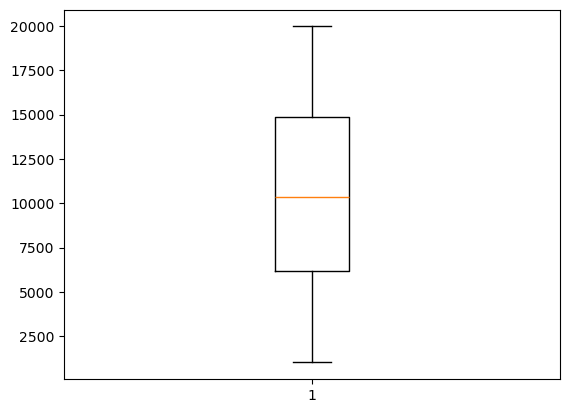

In [13]:
plt.boxplot(df['Target'])
plt.show()

In [14]:
correlation =df.select_dtypes(include='number').corr()

In [15]:
correlation

,Amount,Target
Amount,1.000000,-0.007435
Target,-0.007435,1.000000


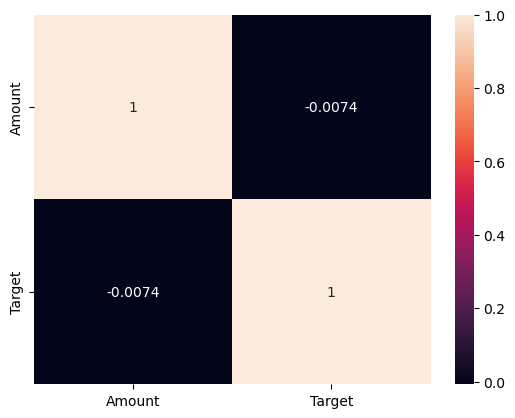

In [16]:
import seaborn 
map = seaborn.heatmap(correlation, annot=True)

In [17]:
df['Date'] = pd.to_datetime(df['Date'])

In [18]:
df['day']         = df['Date'].dt.day
df['month_num']   = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek
df['is_month_end']= df['Date'].dt.is_month_end.astype(int)
df['week_of_year']= df['Date'].dt.isocalendar().week.astype(int)

In [19]:
df = df.sort_values('Date')
df['rolling_7day_avg'] = (
    df['Amount']
    .rolling(window=7, min_periods=1)
    .mean()
)

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from prophet import Prophet
import joblib
le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])

In [21]:
cat_features = ['Amount', 'day', 'month_num', 'day_of_week',
                'is_month_end', 'week_of_year', 'rolling_7day_avg']

X_cat = df[cat_features]
y_cat = df['Category_encoded']

In [22]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

In [23]:
cat_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
cat_model.fit(X_train_cat, y_train_cat)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [24]:
y_pred_cat = cat_model.predict(X_test_cat)
print(classification_report(y_test_cat, y_pred_cat,
      target_names=le.classes_))

               precision    recall  f1-score   support

Entertainment       0.13      0.17      0.14        30
         Food       0.23      0.17      0.19        30
       Health       0.08      0.10      0.09        30
         Rent       0.14      0.14      0.14        29
     Shopping       0.20      0.21      0.20        29
    Transport       0.10      0.10      0.10        29
    Utilities       0.20      0.09      0.12        23

     accuracy                           0.14       200
    macro avg       0.15      0.14      0.14       200
 weighted avg       0.15      0.14      0.14       200



In [25]:
joblib.dump(cat_model, 'models/category_model.pkl')
joblib.dump(le,        'models/label_encoder.pkl')

['models/label_encoder.pkl']

In [26]:
scaler = StandardScaler()
anomaly_features = ['Amount', 'day', 'rolling_7day_avg']
X_anomaly = scaler.fit_transform(df[anomaly_features])

In [27]:
anomaly_model = IsolationForest(
    contamination=0.05,
    n_estimators=100,
    random_state=42
)
anomaly_model.fit(X_anomaly)

IsolationForest(contamination=0.05, random_state=42)

In [28]:
df['anomaly_score'] = anomaly_model.decision_function(X_anomaly)
df['is_anomaly']    = anomaly_model.predict(X_anomaly)

In [29]:
# ── Prepare time series ───────────────────────────────────────────
forecast_df = (
    df.groupby('Date')['Amount']
    .sum()
    .reset_index()
    .rename(columns={'Date': 'ds', 'Amount': 'y'})
)

# This creates train_forecast and test_forecast
train_forecast = forecast_df[:-30]   # everything except last 30 days
test_forecast  = forecast_df[-30:]   # last 30 days for testing

print(f"Training rows: {len(train_forecast)}")
print(f"Test rows:     {len(test_forecast)}")
print(train_forecast.head())

Training rows: 585
Test rows:     30
          ds      y
0 2024-01-01   3279
1 2024-01-02   6351
2 2024-01-05  28049
3 2024-01-08  10856
4 2024-01-09  12857


In [30]:
forecast_df = (
    df.groupby('Date')['Amount']
    .sum()
    .reset_index()
    .rename(columns={'Date': 'ds', 'Amount': 'y'})
)

In [31]:
prophet_model = Prophet(
    seasonality_mode='additive',
    weekly_seasonality=True,
    yearly_seasonality=False,
    changepoint_prior_scale=0.05
)
prophet_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
prophet_model.fit(train_forecast)

02:24:10 - cmdstanpy - INFO - Chain [1] start processing
02:24:10 - cmdstanpy - INFO - Chain [1] done processing


In [32]:
future   = prophet_model.make_future_dataframe(periods=30)
forecast = prophet_model.predict(future)
print(forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(30))

            ds          yhat   yhat_lower    yhat_upper
585 2026-08-12  12570.368460  1005.502497  23710.063557
586 2026-08-13  11853.460331   819.091520  23191.980650
587 2026-08-14  12278.127065  1623.532703  23461.842208
588 2026-08-15  10354.987702 -1211.826160  21685.600130
589 2026-08-16  11599.780989   -68.214957  24064.817946
590 2026-08-17  15109.604917  3287.869779  26525.269897
591 2026-08-18  12617.015294  2107.319989  23900.820792
592 2026-08-19  13541.662280  1837.483375  24894.001628
593 2026-08-20  13712.126316  2324.355488  25481.879352
594 2026-08-21  13938.586832  3106.916615  25133.138980
595 2026-08-22  11029.311900    68.327176  22824.575503
596 2026-08-23  10998.248503  -492.265793  22102.535694
597 2026-08-24  13400.399542  2088.939361  24981.265265
598 2026-08-25  10278.474618 -1410.304294  22239.572186
599 2026-08-26  11215.197712  -714.033238  22734.917534
600 2026-08-27  12057.881768   322.576322  23541.761649
601 2026-08-28  13449.295355  2017.656264  25859

In [33]:
# ── Setup needed for recommendations ─────────────────────────────
category_avg_window = 30

recent = df[
    df['Date'] >= df['Date'].max() - pd.Timedelta(days=category_avg_window)
]

cat_avg = df.groupby('Category')['Amount'].mean()

recommendations = []   # initialise empty list first

print(f"Recent transactions (last {category_avg_window} days): {len(recent)}")
print(recent[['Date','Category','Amount']].head())

Recent transactions (last 30 days): 27
          Date   Category  Amount
973 2026-08-27       Food    5550
974 2026-08-28  Utilities     172
975 2026-08-29   Shopping    4699
976 2026-08-29     Health    1904
977 2026-08-30   Shopping    3456


In [34]:
recent_avg = recent.groupby('Category')['Amount'].mean()

for cat in recent_avg.index:
    if cat in cat_avg and recent_avg[cat] > cat_avg[cat] * 1.2:
        recommendations.append({...})

In [36]:
# Add these lines before the savings_rate calculation
total_spend  = recent['Amount'].sum()
target_total = recent['Target'].sum()  # make sure your column is named 'Target'

savings_rate = (target_total - total_spend) / target_total * 100

if savings_rate < 10:
    recommendations.append({
        'type'   : 'savings',
        'message': f"Your savings rate is {savings_rate:.1f}%. "
                    "Aim to save at least 10% of your target budget monthly."
    })

In [37]:
savings_rate = (target_total - total_spend) / target_total * 100
if savings_rate < 10:
    recommendations.append({...})

In [38]:
print(df.columns.tolist())  # check if it's 'Target' or 'Target_Amount'

['Date', 'Category', 'Amount', 'Payment_Mode', 'Month', 'Target', 'day', 'month_num', 'day_of_week', 'is_month_end', 'week_of_year', 'rolling_7day_avg', 'Category_encoded', 'anomaly_score', 'is_anomaly']


In [39]:
import os

# Check if models folder and files exist
print("Folder exists:", os.path.exists('models'))
print("Files in models folder:")

if os.path.exists('models'):
    print(os.listdir('models'))
else:
    print("models/ folder does not exist yet - you need to train and save first")

Folder exists: True
Files in models folder:
['category_model.pkl', 'label_encoder.pkl', 'outputs', 'spend_model.joblib']


In [41]:
# STEP 1 — Create the models folder
import os
os.makedirs('models', exist_ok=True)
print("models/ folder ready")

models/ folder ready


In [42]:
# STEP 2 — Train and save categorisation model
joblib.dump(cat_model, 'models/category_model.pkl')
joblib.dump(le,        'models/label_encoder.pkl')
print("Saved: category_model.pkl and label_encoder.pkl")

Saved: category_model.pkl and label_encoder.pkl


In [43]:
# STEP 3 — Train and save anomaly model
joblib.dump(anomaly_model, 'models/anomaly_model.pkl')
joblib.dump(scaler,        'models/scaler.pkl')
print("Saved: anomaly_model.pkl and scaler.pkl")

Saved: anomaly_model.pkl and scaler.pkl


In [44]:
# STEP 4 — Train and save prophet model
joblib.dump(prophet_model, 'models/prophet_model.pkl')
print("Saved: prophet_model.pkl")

Saved: prophet_model.pkl


In [45]:
# STEP 5 — Verify all files are present before loading
expected = [
    'models/category_model.pkl',
    'models/label_encoder.pkl',
    'models/anomaly_model.pkl',
    'models/scaler.pkl',
    'models/prophet_model.pkl'
]

for f in expected:
    status = "EXISTS" if os.path.exists(f) else "MISSING"
    print(f"{status} → {f}")

EXISTS → models/category_model.pkl
EXISTS → models/label_encoder.pkl
EXISTS → models/anomaly_model.pkl
EXISTS → models/scaler.pkl
EXISTS → models/prophet_model.pkl


In [46]:
cat_model     = joblib.load('models/category_model.pkl')
label_encoder = joblib.load('models/label_encoder.pkl')
anomaly_model = joblib.load('models/anomaly_model.pkl')
scaler        = joblib.load('models/scaler.pkl')
prophet_model = joblib.load('models/prophet_model.pkl')

In [48]:
def predict_category(amount, day, month_num,):
    features = np.array([[amount, day, month_num, ...]])
    encoded  = cat_model.predict(features)[0]
    return label_encoder.inverse_transform([encoded])[0]

In [49]:
def detect_anomaly(amount, day, rolling_avg):
    features = scaler.transform([[amount, day, rolling_avg]])
    score    = anomaly_model.decision_function(features)[0]
    flag     = anomaly_model.predict(features)[0]
    return {'is_anomaly': flag == -1, 'score': round(score, 4)}

In [51]:
from pydantic import BaseModel 
class TransactionInput(BaseModel):
    amount      : float
    day         : int
    ...

In [53]:
from fastapi import FastAPI
app = FastAPI(title="FinTrack API", description="ML-powered finance API")
@app.post("/predict-category")
def predict(tx: TransactionInput):
    category = predict_category(tx.amount, tx.day, ...)
    return {"predicted_category": category}